# Linear Time Series and Conditional Volatility

Notebook 07 established the process–realization distinction, stationarity and ergodicity. I now introduce explicit models of temporal dependence. AR, MA, ARMA and ARIMA describe conditional-mean dynamics. ARCH and GARCH describe conditional-variance dynamics. These are different targets, even when estimated jointly.

AR(1) is the central mean-model example. The course's inflation series illustrates estimation and forecasting, while its ARCH(1) simulation makes variance dependence visible before the financial capstone.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from finstats.timeseries.diagnostics import acf, sample_autocorrelation, ljung_box
from finstats.timeseries.ar import (
    simulate_ar1, ar1_unconditional_variance, ar1_acf, ar_roots,
    is_stationary_ar, ar1_forecast,
)
from finstats.timeseries.ma import simulate_ma, ma_roots, is_invertible_ma
from finstats.timeseries.arma import arma_roots
from finstats.timeseries.nonstationary import difference, simulate_random_walk
from finstats.timeseries.forecasting import forecast_mse, forecast_rmse, forecast_mae

# A plotting helper only; statistical calculations remain explicit in each cell.
def stem_dependence(ax, values, title, ylabel="Correlation"):
    lags = np.arange(len(values))
    ax.vlines(lags, 0, values, color="C0", linewidth=1.2)
    ax.scatter(lags, values, s=10, color="C0")
    ax.axhline(0, color="0.6", linewidth=.8)
    ax.set(xlabel="Lag", ylabel=ylabel, title=title)

from arch import arch_model
from finstats.timeseries.diagnostics import acf, ljung_box, mcleod_li, standardized_residuals
from finstats.timeseries.volatility import (
    simulate_arch1, arch1_unconditional_variance, simulate_garch11,
    garch11_unconditional_variance, garch11_variance_path, garch11_forecast,
)
from finstats.nonparametric import qq_data

def dependence_panel(ax, values, title):
    lags = np.arange(len(values))
    ax.vlines(lags,0,values,color="C0",linewidth=1.2)
    ax.axhline(0,color="0.6",linewidth=.8)
    ax.set(xlabel="Lag",ylabel="Sample correlation",title=title)

## 1. Linear Stochastic Processes

A linear process represents observations as a weighted sum of current and past shocks. Lagged coefficients determine how an innovation propagates. Write $BX_t=X_{t-1}$ and $B^jX_t=X_{t-j}$ for the backshift operator.

### Wold representation

A finite-variance weakly stationary process has a decomposition into a deterministic, perfectly linearly predictable component and a stochastic component,
$$X_t=\mu+V_t+\sum_{j=0}^{\infty}\psi_j\varepsilon_{t-j},\qquad
\psi_0=1,\quad\sum_j\psi_j^2<\infty.$$
Here the innovations are orthogonal linear-prediction errors. For a purely nondeterministic process $V_t=0$. The square-summability condition makes the infinite sum converge in mean square. Wold provides the population linear-prediction structure; it does not claim every stationary process is a finite ARMA model or has independent innovations.

### AR(1): definition and properties

For the causal stationary model,
$$X_t-\mu=\phi(X_{t-1}-\mu)+\varepsilon_t,\qquad
(1-\phi B)(X_t-\mu)=\varepsilon_t.$$
Repeated substitution yields
$$X_t-\mu=\phi^m(X_{t-m}-\mu)+\sum_{j=0}^{m-1}\phi^j\varepsilon_{t-j}.$$
If $|\phi|<1$ and variance is finite, the first term vanishes in mean square, so
$$X_t-\mu=\sum_{j=0}^{\infty}\phi^j\varepsilon_{t-j}.$$
Since innovations have mean zero, $E[X_t]=\mu$. Uncorrelated innovations give
$$\gamma_0=\sigma^2\sum_{j=0}^{\infty}\phi^{2j}=\frac{\sigma^2}{1-\phi^2}.$$
For $j>0$, multiply the recursion by $X_{t-j}-\mu$ and take expectations. The current innovation is orthogonal to the past, giving $\gamma_j=\phi\gamma_{j-1}$. Therefore
$$\gamma_j=\phi^j\gamma_0,\qquad\rho_j=\phi^j.$$
The root of $1-\phi z=0$ is $1/\phi$, outside the unit circle exactly when $|\phi|<1$ (at $\phi=0$ there is no finite root). Root conditions here refer to the causal solution driven by past innovations.

With innovations whose conditional mean given the past is zero,
$$E[X_t\mid\mathcal F_{t-1}]=\mu+\phi(X_{t-1}-\mu).$$
White-noise covariance conditions alone do not imply this conditional-mean statement. IID shocks independent of the past provide it. In the intercept form $X_t=c+\phi X_{t-1}+\varepsilon_t$, $c=(1-\phi)\mu$.

For illustration, I retain Gaussian innovations with variance one, length 300 and the course's $\phi=.7$ example. Comparing $\phi=0,.7,-.7$ shows absence, persistence and alternating dependence. Seed 510 is fixed, with each path initialized from its stationary Gaussian distribution.

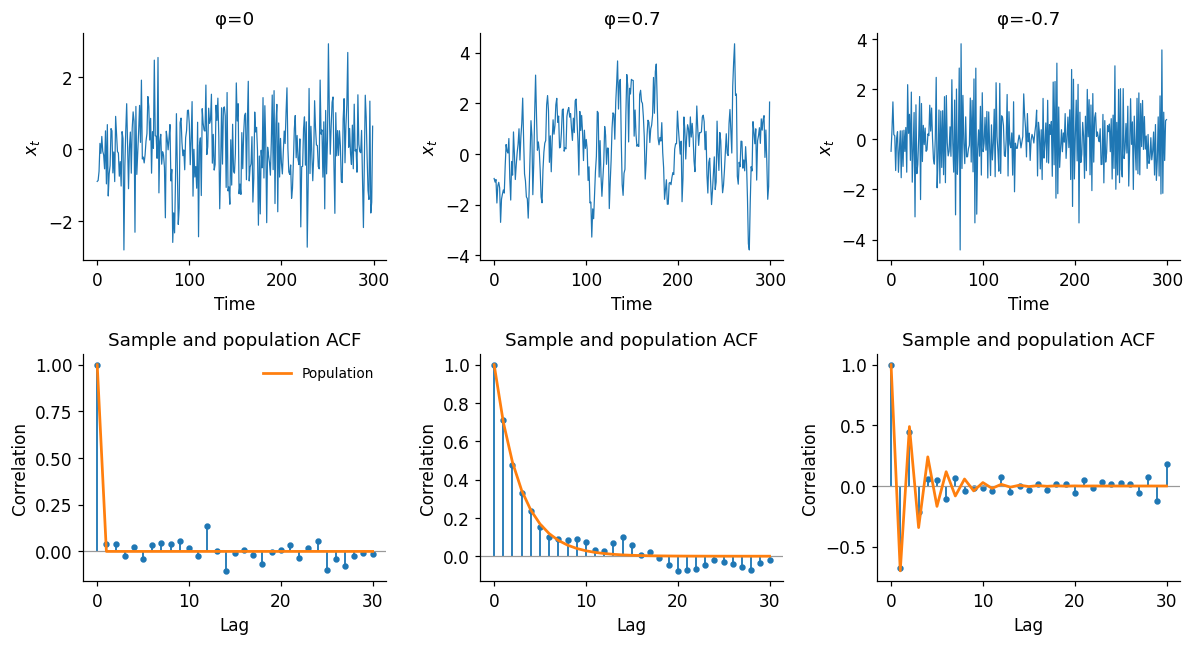

,φ,Population variance,Sample variance
0,0.0,1.000000,0.998678
1,0.7,1.960784,1.932061
2,-0.7,1.960784,1.728957


In [2]:
rng_persistence = np.random.default_rng(510)
phis = [0., .7, -.7]
persistence_paths = {phi:simulate_ar1(phi, 1, 300, rng=rng_persistence) for phi in phis}
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for column, phi in enumerate(phis):
    values = persistence_paths[phi]
    axes[0, column].plot(values, linewidth=.8)
    axes[0, column].set(title=f"φ={phi:g}", xlabel="Time", ylabel="$x_t$")
    stem_dependence(axes[1, column], acf(values, 30), "Sample and population ACF")
    axes[1, column].plot(np.arange(31), ar1_acf(phi, 30), color="C1", label="Population")
axes[1, 0].legend(fontsize=9)
fig.tight_layout()
plt.show()
display(pd.DataFrame([{"φ":phi, "Population variance":ar1_unconditional_variance(phi, 1), "Sample variance":sample_variance(values)} for phi, values in persistence_paths.items()]))

### AR(p): generalization

The centered model is
$$X_t-\mu=\sum_{i=1}^p\phi_i(X_{t-i}-\mu)+\varepsilon_t,\qquad
\phi(z)=1-\phi_1z-\cdots-\phi_pz^p.$$
The causal stationary solution requires $\phi(z)\ne0$ for every $|z|\le1$, equivalently all roots outside the unit circle.

The Yule–Walker equations connect coefficients and covariance:
$$\gamma_0=\sum_{i=1}^p\phi_i\gamma_i+\sigma^2,\qquad
\gamma_j=\sum_{i=1}^p\phi_i\gamma_{j-i},\quad j>0,$$
with $\gamma_{-j}=\gamma_j$. They arise by multiplying the model by its lagged centered values and taking expectations. The PACF at lag $j$ measures remaining linear association after accounting for intervening lags; an AR($p$) population has zero PACF after lag $p$.

### Moving-average processes

An MA($q$) is
$$X_t=\mu+\varepsilon_t+\sum_{j=1}^q\theta_j\varepsilon_{t-j}
=\mu+\theta(B)\varepsilon_t.$$
A finite linear combination of white noise is weakly stationary. Its autocovariance is zero beyond lag $q$ because the innovation sets no longer overlap.

For MA(1),
$$X_t=\mu+\varepsilon_t+\theta\varepsilon_{t-1}.$$
Uncorrelated innovations give
$$\gamma_0=\sigma^2(1+\theta^2),\qquad
\gamma_1=\theta\sigma^2,\qquad
\rho_1=\frac\theta{1+\theta^2},\quad\rho_j=0\ (j>1).$$
Only the shared $\varepsilon_{t-1}$ contributes to lag-one covariance.

### ARMA(p,q)

Combine both components:
$$X_t-\mu=\sum_{i=1}^p\phi_i(X_{t-i}-\mu)+\varepsilon_t+\sum_{j=1}^q\theta_j\varepsilon_{t-j},$$
$$\phi(B)(X_t-\mu)=\theta(B)\varepsilon_t.$$
Here $\phi(B)=1-\sum_i\phi_iB^i$ and $\theta(B)=1+\sum_j\theta_jB^j$. AR roots outside the unit circle give a causal stationary solution; MA roots outside give invertibility. Common AR and MA factors cancel, so retaining them would create an unnecessarily high-order representation.

A causal solution has $X_t=\mu+\sum_{j\ge0}\psi_j\varepsilon_{t-j}$. An invertible solution has $X_t=\mu+\sum_{j\ge1}\pi_j(X_{t-j}-\mu)+\varepsilon_t$. These are infinite linear filters, not claims that all coefficients need to be estimated individually.

### Invertibility and ACF/PACF identification

For $\theta(z)=1+\theta_1z+\cdots+\theta_qz^q$, invertibility requires roots outside the unit circle. It allows innovations to be recovered as a convergent linear filter of current and past observations. MA(1) is stationary for any finite $\theta$, but invertible only when $|\theta|<1$. AR roots govern **causal stationarity**; MA roots govern **invertibility**.

| Population process | ACF | PACF |
|---|---|---|
| AR($p$) | Decays | Cuts off after $p$ |
| MA($q$) | Cuts off after $q$ | Decays |
| ARMA($p,q$) | Decays | Decays |

These are population patterns for nondegenerate minimal representations. Sample ACF/PACF can be noisy, particularly in short samples. The patterns guide candidate specification rather than identify a model mechanically.

## 2. Non-stationarity, Differencing and ARIMA

### Lag operator and differencing

The backshift operator satisfies $BX_t=X_{t-1}$ and $B^jX_t=X_{t-j}$. Thus $\Delta X_t=(1-B)X_t$, and repeated differences are $(1-B)^dX_t$. These are operators on a process; applying them to observed data removes the initial observations needed for each difference. The random walk has $(1-B)Y_t=\varepsilon_t$.

### ARIMA and differencing

An ARIMA($p,d,q$) models $(1-B)^dX_t$ as ARMA($p,q$):
$$\phi(B)(1-B)^d(X_t-\mu)=\theta(B)\varepsilon_t.$$
The orders count AR lags, differences, and MA lags. For $d>0$ a constant $\mu$ in levels is annihilated by differencing; a nonzero mean of the differenced series corresponds to drift and needs separate treatment. The random walk is ARIMA(0,1,0), since $\Delta Y_t=\varepsilon_t$.

Notebook 07 showed why a random walk has a stochastic trend. Here differencing becomes a modeling procedure: a unit root means an AR polynomial has a root at one, and an integrated process of order $d$ becomes stationary after $d$ differences. A deterministic trend instead motivates modeling or removing the trend, rather than automatically imposing a difference.

The augmented Dickey–Fuller test examines a unit-root null using a regression in differences with lagged levels and, where needed, lagged differences. Its reference distribution is not an ordinary Student-t law. The constant/trend specification and lag choice affect interpretation. Rejection provides evidence against the specified unit-root null, rather than proving stationarity in every respect. Notebook 09 uses this diagnostic without treating a test result as proof.

## 3. Estimation and Model Diagnostics

### Estimating linear time-series models

Population disturbances and fitted residuals are different:
$$\varepsilon_t=(X_t-\mu)-\phi(X_{t-1}-\mu),\qquad
\hat\varepsilon_t=(x_t-\hat\mu)-\hat\phi(x_{t-1}-\hat\mu).$$
Disturbances belong to the population model; residuals use estimated parameters and observed data. A Gaussian working likelihood can estimate ARMA/ARIMA models. Exact state-space likelihood accounts for initial-state uncertainty; a conditional likelihood conditions on initial observations. Software conventions must be identified rather than silently compared.

### Model identification and selection

ACF/PACF patterns motivate a small candidate set rather than an exhaustive search. Among fits to the same observations and transformation,
$$AIC=-2\ell(\hat\psi)+2k,\qquad BIC=-2\ell(\hat\psi)+k\log T.$$
Lower values trade fit against complexity. Include fitted variance in $k$. Information criteria do not replace residual diagnostics; compare different differencing choices cautiously because likelihood and effective observations can differ. The empirical example fixes the transformation before comparing its candidates.

### Residual diagnostics

A fitted conditional-mean model should leave little linear dependence in its residuals. Inspect their path and ACF. The Ljung–Box statistic is
$$Q_{LB}=T(T+2)\sum_{j=1}^h\frac{\hat\rho_j^2}{T-j}.$$
Under $H_0:\rho_1=\cdots=\rho_h=0$, an approximate reference is $\chi^2_{h-p-q}$ after fitting ARMA($p,q$). Require $h>p+q$. The production convention uses denominator-$T$ autocovariances for $\hat\rho_j$, unlike the earlier course-adjusted exploratory ACF. The helper is tested against statsmodels under matching conventions.



For illustration, I fit AR(1) to the preceding φ=.7 history using state-space Gaussian likelihood. The ARIMA interface also fits AR, MA and ARMA through d=0 and the corresponding p/q orders. The same interface handles d>0 in the inflation example below.

In [3]:
limited_fit = ARIMA(persistence_paths[.7],order=(1,0,0),trend="c").fit()
assert limited_fit.mle_retvals.get("converged",True)
display(pd.DataFrame({"estimate":limited_fit.params,"standard error":limited_fit.bse},index=limited_fit.param_names).round(4))
print(f"Log-likelihood={limited_fit.llf:.3f}; unconditional mean estimate={limited_fit.params[0]:.4f}; AR coefficient={limited_fit.arparams[0]:.4f}")

,estimate,standard error
const,0.3116,0.1948
ar.L1,0.7132,0.0413
sigma2,0.9475,0.0795


Log-likelihood=-417.957; unconditional mean estimate=0.3116; AR coefficient=0.7132


In [4]:
limited_residuals = np.asarray(limited_fit.resid)[1:]
display(pd.DataFrame([ljung_box(limited_residuals, h, model_df=1) for h in (10, 20)]))

,statistic,p_value,df,lags,nobs
0,4.748893,0.855626,9,10,299
1,16.737606,0.607639,19,20,299


## 4. Forecasting

### Forecasting as conditional expectation

Let $\mathcal F_t$ be information available at forecast origin $t$. Under squared-error loss,
$$\hat X_{t+h|t}=E[X_{t+h}\mid\mathcal F_t]$$
minimizes expected error, because for any $\mathcal F_t$-measurable forecast $g$,
$$E[(X_{t+h}-g)^2\mid\mathcal F_t]
=\operatorname{Var}(X_{t+h}\mid\mathcal F_t)+(E[X_{t+h}\mid\mathcal F_t]-g)^2.$$
For AR(1), assume innovations are independent of the past with conditional mean zero; white-noise covariance alone is insufficient for a general conditional-expectation assertion. Taking conditional expectations gives
$$\hat X_{t+1|t}=\mu+\phi(X_t-\mu).$$
Iterating the same argument gives
$$\hat X_{t+h|t}=\mu+\phi^h(X_t-\mu).$$
For $|\phi|<1$, the forecast converges to $\mu$, revealing mean reversion.

### Forecast uncertainty and evaluation

Forecast error is $e_{t+h|t}=X_{t+h}-\hat X_{t+h|t}$. It concerns an unknown future observation, whereas estimator MSE in Notebook 03 concerns an unknown fixed parameter. Even with known parameters, future innovations create forecast uncertainty.

For the Gaussian AR(1), iteration gives
$$e_{t+h|t}=\sum_{j=0}^{h-1}\phi^j\varepsilon_{t+h-j},\qquad
\operatorname{Var}(e_{t+h|t})=\sigma^2\sum_{j=0}^{h-1}\phi^{2j}
=\sigma^2\frac{1-\phi^{2h}}{1-\phi^2}.$$
This approaches the unconditional variance. Gaussian prediction intervals add/subtract the corresponding normal quantile times forecast SD. Fitted-model intervals typically condition on estimated parameters and do not fully include parameter uncertainty.

For a holdout of $H$ observations,
$$MSE=H^{-1}\sum_he_h^2,\quad RMSE=\sqrt{MSE},\quad MAE=H^{-1}\sum_h|e_h|.$$
RMSE and MAE have observation units, while MSE has squared units. The holdout workflow below is a compact application, not a forecast competition.

### Inflation estimation and forecasting

Use `data/ecdat_mishkin.csv`, column `pai1`: monthly one-month U.S. inflation expressed as an annualized percentage rate, February 1950–December 1990, 491 observations. Monthly dates are reconstructed from the documented regular sequence. No values are filled, rescaled, or removed. The last 24 observations form a fixed holdout; all candidate selection uses only the first 467.

For illustration, I compare the ACF of the inflation level with the ACF of its first difference on the training sample. A persistent level ACF motivates considering differencing, but a plot alone cannot establish a unit root. I use the course-style differenced formulation for the fixed candidate comparison; this is a modeling decision, not a stationarity-test conclusion.

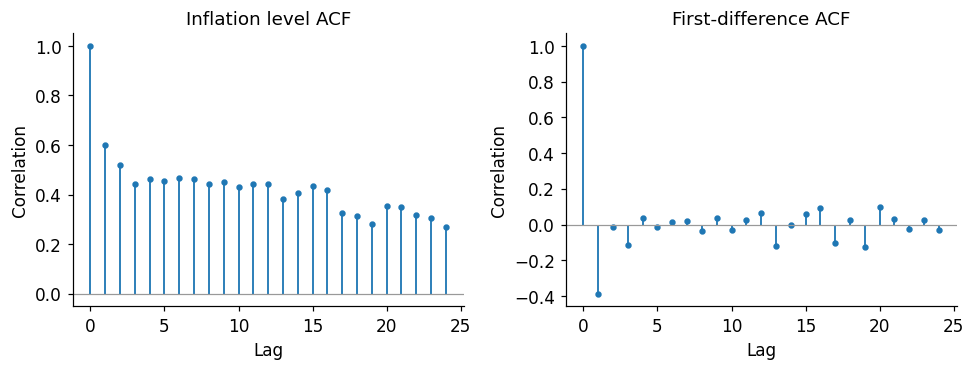

In [5]:
inflation_frame = pd.read_csv(repository / "data/ecdat_mishkin.csv")
inflation = inflation_frame["pai1"].to_numpy(dtype=float)
inflation_dates = pd.date_range("1950-02-01",periods=491,freq="MS")
assert len(inflation)==491 and np.isfinite(inflation).all()
holdout = 24
inflation_train, inflation_test = inflation[:-holdout],inflation[-holdout:]
inflation_differences = difference(inflation_train)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, values, title in ((axes[0], inflation_train, "Inflation level ACF"), (axes[1], inflation_differences, "First-difference ACF")):
    stem_dependence(ax, acf(values, 24), title)
fig.tight_layout()
plt.show()

For illustration, I compare ARIMA(0,1,1), ARIMA(1,1,0), and ARIMA(1,1,1), all without drift and fitted to the same training levels using state-space Gaussian likelihood. Select the smallest AIC in this prespecified set, report coefficient uncertainty, then inspect residual ACF and Ljung–Box. Exclude the first residual affected by diffuse level initialization from the diagnostics, and deduct $p+q$ degrees of freedom. Selection does not guarantee adequate residuals.

In [6]:
inflation_models = {}
for order in [(0,1,1),(1,1,0),(1,1,1)]:
    fit = ARIMA(inflation_train,order=order,trend="n").fit()
    if not fit.mle_retvals.get("converged",True): raise RuntimeError(f"Nonconverged inflation candidate {order}")
    inflation_models[order] = fit
inflation_order = min(inflation_models,key=lambda order:inflation_models[order].aic)
inflation_fit = inflation_models[inflation_order]
display(pd.DataFrame([{"order":str(order),"log-likelihood":fit.llf,"AIC":fit.aic,"BIC":fit.bic} for order,fit in inflation_models.items()]).round(3))
print("Selected within this candidate set:",inflation_order)
display(pd.DataFrame({"estimate":inflation_fit.params,"standard error":inflation_fit.bse},index=inflation_fit.param_names).round(5))
inflation_residuals = np.asarray(inflation_fit.resid)[1:]
display(pd.DataFrame([ljung_box(inflation_residuals,h,model_df=inflation_order[0]+inflation_order[2]) for h in [12,24]]).round(5))

,order,log-likelihood,AIC,BIC
0,"(0, 1, 1)",-1167.806,2339.611,2347.900
1,"(1, 1, 0)",-1203.411,2410.822,2419.111
2,"(1, 1, 1)",-1159.923,2325.846,2338.279


Selected within this candidate set: (1, 1, 1)


,estimate,standard error
ar.L1,0.22915,0.03532
ma.L1,-0.86985,0.02006
sigma2,8.48341,0.32326


,statistic,p_value,df,lags,nobs
0,8.57269,0.57308,10,12,466
1,32.62348,0.06737,22,24,466


For illustration, I forecast the fixed 24-month holdout from one origin without accessing its values during fitting. Show model-based 95% prediction intervals, compare against a last-observed-level benchmark, and report MSE/RMSE/MAE. A nonstationary integrated model need not have forecast uncertainty approaching a stationary long-run bound. A single holdout does not establish general predictive superiority.

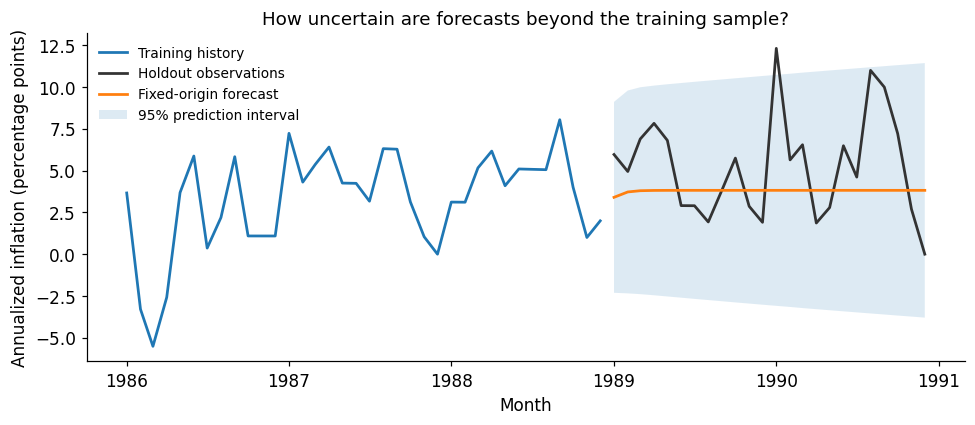

,forecast,MSE,RMSE,MAE
0,Selected ARIMA,11.1906,3.3452,2.6494
1,Last level,19.5896,4.4260,3.4313


In [7]:
inflation_prediction = inflation_fit.get_forecast(steps=holdout)
inflation_forecast = np.asarray(inflation_prediction.predicted_mean)
inflation_intervals = np.asarray(inflation_prediction.conf_int(alpha=.05))
benchmark = np.full(holdout,inflation_train[-1])
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(inflation_dates[len(inflation_train)-36:len(inflation_train)],inflation_train[-36:],label="Training history")
ax.plot(inflation_dates[-holdout:],inflation_test,color="0.2",label="Holdout observations")
ax.plot(inflation_dates[-holdout:],inflation_forecast,label="Fixed-origin forecast")
ax.fill_between(inflation_dates[-holdout:],inflation_intervals[:,0],inflation_intervals[:,1],alpha=.15,label="95% prediction interval")
ax.set(xlabel="Month",ylabel="Annualized inflation (percentage points)",title="How uncertain are forecasts beyond the training sample?")
ax.legend(fontsize=9);fig.tight_layout();plt.show()
display(pd.DataFrame([{"forecast":label,"MSE":forecast_mse(inflation_test,values),"RMSE":forecast_rmse(inflation_test,values),"MAE":forecast_mae(inflation_test,values)} for label,values in [("Selected ARIMA",inflation_forecast),("Last level",benchmark)]]).round(4))

The selected model is preferred only among the three candidates on the stated transformation and sample. Residual diagnostics and the holdout errors can reveal limitations despite a favorable AIC. Inflation is not a financial return series; its annualized rate units and integration decision should not be transferred mechanically to daily returns.

## 5. Conditional Heteroskedastic Processes

Volatility clustering concerns the magnitude of movements. A series can have little signed-return autocorrelation while its squared values retain dependence. Conditional variance can change with the observed past even when unconditional variance is constant.

### Conditional versus unconditional variance

Let $\mathcal F_{t-1}$ contain information available before observation $t$. For a mean-zero innovation $a_t$, distinguish
$$\operatorname{Var}(a_t)\qquad\text{from}\qquad
\operatorname{Var}(a_t\mid\mathcal F_{t-1})=\sigma_t^2.$$
The first averages over possible histories. The second changes with the observed past. If $E[a_t\mid\mathcal F_{t-1}]=0$, the law of total variance gives $\operatorname{Var}(a_t)=E[\sigma_t^2]$. Stable unconditional variance therefore permits time-varying conditional variance.

### ARCH(1)

Define
$$a_t=\sigma_t\nu_t,\qquad\sigma_t^2=\omega+\alpha a_{t-1}^2,$$
where $\nu_t$ is iid with mean zero, variance one, and independent of past information. Initially assume $\nu_t\sim N(0,1)$; Gaussianity is an additional distributional assumption. Positivity requires $\omega>0$, $\alpha\ge0$. The finite unconditional-variance stationary solution requires $\alpha<1$.

The notation $\sigma_t$ denotes conditional standard deviation; $\sigma_t^2$ is conditional variance. A large previous squared shock increases the next variance irrespective of its sign.

### ARCH(1) properties

Since $\sigma_t$ is determined by the past,
$$E[a_t\mid\mathcal F_{t-1}]=\sigma_tE[\nu_t\mid\mathcal F_{t-1}]=0,$$
so $E[a_t]=0$. Also
$$\operatorname{Var}(a_t\mid\mathcal F_{t-1})=\sigma_t^2E[\nu_t^2]=\omega+\alpha a_{t-1}^2.$$
For a stationary solution, put $v=E[a_t^2]$. Taking expectations yields
$$v=\omega+\alpha v\quad\Longrightarrow\quad
\operatorname{Var}(a_t)=\frac\omega{1-\alpha}.$$
This is a constant population moment. It does not say that every realized conditional variance or sample variance equals $v$.

### ARCH and dependence in squared returns

For $s<t$, $a_s$ is past-measurable, so
$$E[a_sa_t]=E[a_sE(a_t\mid\mathcal F_{t-1})]=0.$$
Thus returns can be serially uncorrelated without being independent. Define $\eta_t=a_t^2-\sigma_t^2$. Its conditional mean is zero, and substitution gives
$$a_t^2=\omega+\alpha a_{t-1}^2+\eta_t.$$
This is an AR(1)-type recursion in squares. **If fourth moments are finite**, $\eta_t$ has finite variance and the squared process has $\operatorname{Corr}(a_t^2,a_{t-j}^2)=\alpha^j$.

The moment qualification matters. With Gaussian $\nu_t$, $E[\nu_t^4]=3$ and
$$E[a_t^4]=3E[(\omega+\alpha a_{t-1}^2)^2].$$
Solving requires $3\alpha^2<1$. The course example $\alpha=0.8$ violates this: it has finite return variance but infinite fourth moment, so the population correlation of squares is undefined. A sample squared-return ACF remains computable, but must not be presented as an estimate of $\alpha^j$ for that example.

### Course ARCH(1) illustration

For illustration, I retain ω=2, α=.8, n=300 and seed 123, with Gaussian innovations and a 1000-observation burn-in. One figure compares realized shocks, conditional standard deviation, and sample dependence in levels and squares. The population return variance is ten. The squared ACF is descriptive here because this example has no finite fourth moment.

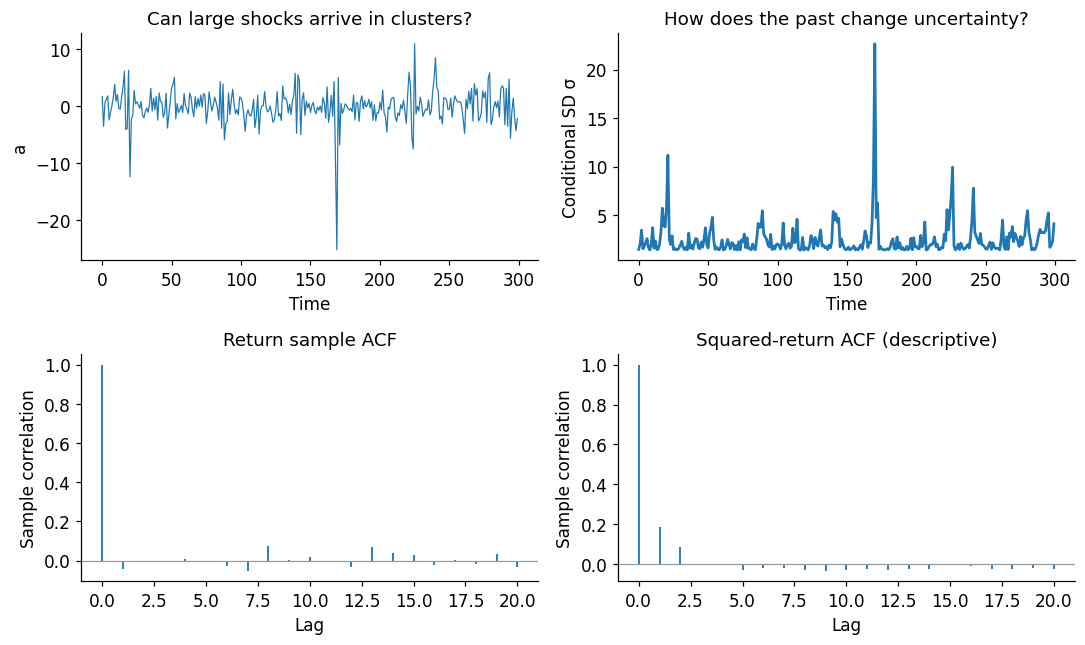

Course ARCH variance: population=10.0000; realized=9.0424


In [8]:
arch_returns, arch_variances = simulate_arch1(2,.8,300,rng=123)
fig, axes = plt.subplots(2,2,figsize=(10,6))
axes[0,0].plot(arch_returns,linewidth=.8);axes[0,0].set(xlabel="Time",ylabel="a",title="Can large shocks arrive in clusters?")
axes[0,1].plot(np.sqrt(arch_variances));axes[0,1].set(xlabel="Time",ylabel="Conditional SD σ",title="How does the past change uncertainty?")
dependence_panel(axes[1,0],acf(arch_returns,20),"Return sample ACF")
dependence_panel(axes[1,1],acf(arch_returns**2,20),"Squared-return ACF (descriptive)")
fig.tight_layout();plt.show()
print(f"Course ARCH variance: population={arch1_unconditional_variance(2,.8):.4f}; realized={sample_variance(arch_returns):.4f}")

### ARCH(q)

Generalize to
$$\sigma_t^2=\omega+\sum_{j=1}^q\alpha_j a_{t-j}^2.$$
With nonnegative coefficients and $\omega>0$, $\sum_j\alpha_j<1$ gives a finite stationary return variance
$$\operatorname{Var}(a_t)=\frac\omega{1-\sum_j\alpha_j}.$$
Substitution with $\eta_t$ gives an AR($q$)-type recursion for squares. Covariance stationarity of the squared process additionally needs finite fourth moments; the return-variance condition alone does not supply them. Many ARCH lags can be cumbersome, motivating GARCH's parsimonious variance feedback.

### GARCH(1,1)

The flagship recursion is
$$a_t=\sigma_t\nu_t,\qquad
\sigma_t^2=\omega+\alpha a_{t-1}^2+\beta\sigma_{t-1}^2,$$
with $\omega>0$, $\alpha,\beta\ge0$. The intercept $\omega$ is a variance input, not itself long-run variance. The coefficient $\alpha$ governs response to the latest squared shock; $\beta$ carries previous conditional variance forward.

### GARCH stationarity and long-run variance

For unit-variance innovations and a finite-variance stationary solution,
$$v=E[\sigma_t^2]=\omega+\alpha E[a_{t-1}^2]+\beta E[\sigma_{t-1}^2]
=\omega+(\alpha+\beta)v.$$
Thus, when $\alpha+\beta<1$,
$$\sigma_\infty^2=\operatorname{Var}(a_t)=\frac\omega{1-\alpha-\beta}.$$
Persistence near one implies slow variance reversion. At or above one, this finite long-run variance is unavailable; a finite numerical fit or forecast does not change that fact. The condition concerns finite unconditional second moments, not every higher moment.

### GARCH as ARMA in squared returns

Since $\sigma_{t-1}^2=a_{t-1}^2-\eta_{t-1}$,
$$\begin{aligned}
a_t^2&=\omega+\alpha a_{t-1}^2+\beta\sigma_{t-1}^2+\eta_t\\
&=\omega+(\alpha+\beta)a_{t-1}^2-\beta\eta_{t-1}+\eta_t.
\end{aligned}$$
This has an ARMA(1,1)-type squared-observation representation, connecting to the linear models above. A conventional covariance-stationary ARMA interpretation of squares needs finite fourth moments of returns. The algebraic recursion itself does not.

Under the course convention, GARCH($p,q$) has $q$ squared-shock lags and $p$ variance lags:
$$\sigma_t^2=\omega+\sum_{i=1}^q\alpha_i a_{t-i}^2+\sum_{j=1}^p\beta_j\sigma_{t-j}^2.$$
Padding missing coefficients with zeros yields squares of ARMA($\max(p,q),p$) type. The Python package names its shock-lag count `p` and variance-lag count `q`; for (1,1) they coincide. This naming difference does not change the equation.

## 6. Volatility Estimation, Diagnostics and Forecasting

### Estimating GARCH models

For a specified innovation density, maximize the **conditional** likelihood. Under Gaussian innovations, apart from initialization,
$$\ell=-\frac12\sum_t\left[\log(2\pi)+\log\sigma_t^2+\frac{a_t^2}{\sigma_t^2}\right].$$
The variance recursion makes each contribution depend on earlier observations and parameters. Use the mature `arch` estimator for computation. A joint mean/variance specification can use $r_t=c+\phi r_{t-1}+a_t$, with GARCH(1,1) variance. Here $c$ is a recursion intercept, not the unconditional mean $c/(1-\phi)$. The following simulation fixes the mean at zero to isolate variance estimation.

### Estimation on a known simulated population

For illustration, I simulate 1500 observations from Gaussian GARCH(1,1), with ω=.05, α=.05, β=.9 and seed 612. The conditional mean is zero and the population variance is one. Gaussian and standardized Student-t fits use the same observations. This illustrates estimation and diagnostics without repeating the empirical S&P 500 workflow reserved for Notebook 09.

In [9]:
simulated_returns, simulated_variances = simulate_garch11(.05, .05, .9, 1500, rng=612)
returns = pd.Series(simulated_returns, name="simulated shock")
gaussian_garch = arch_model(returns, mean="Zero", vol="GARCH", p=1, q=1, dist="normal", rescale=False).fit(disp="off", update_freq=0)
student_garch = arch_model(returns, mean="Zero", vol="GARCH", p=1, q=1, dist="t", rescale=False).fit(disp="off", update_freq=0)
for fit in (gaussian_garch, student_garch):
    if fit.convergence_flag != 0:
        raise RuntimeError("Variance-model fit did not converge")
display(pd.DataFrame({"Gaussian estimate":gaussian_garch.params, "Student-t estimate":student_garch.params}))
display(pd.DataFrame([{"Innovations":label, "Log-likelihood":fit.loglikelihood, "AIC":fit.aic, "BIC":fit.bic} for label, fit in (("Gaussian", gaussian_garch), ("Student-t", student_garch))]))

,Gaussian estimate,Student-t estimate
alpha[1],0.042640,0.042295
beta[1],0.919807,0.920060
nu,NaN,140.640100
omega,0.036353,0.036482


,Innovations,Log-likelihood,AIC,BIC
0,Gaussian,-2094.284856,4194.569711,4210.509372
1,Student-t,-2094.804595,4197.609191,4218.862072


### Gaussian versus Student-t innovations

Begin with $\nu_t\sim N(0,1)$. A Gaussian QQ diagnostic checks whether fitted standardized shocks have the assumed tail shape. Time-varying variance can explain some unconditional heavy tails, but conditional heavy tails may remain.

The alternative uses **unit-variance** Student-t innovations,
$$\nu_t=\sqrt{\frac{d-2}{d}}T_d,\qquad d>2.$$
This is different from the unit-scale $t_d$ in Notebook 01; the normalization keeps $\sigma_t^2$ a conditional variance. The `arch` package uses this standardized convention.

If fitted Student-t degrees of freedom are at most four, squared standardized shocks lack finite variance. Their ACF remains descriptive, and the nominal squared-portmanteau p-value is omitted. Unit-variance shocks require degrees of freedom above two.

### Standardized residuals

Construct
$$\hat\nu_t=\hat a_t/\hat\sigma_t.$$
A satisfactory specification should leave little linear dependence in $\hat\nu_t$ or $\hat\nu_t^2$. This is necessary diagnostic evidence, not proof of independence or model truth.



### Detecting ARCH effects

After a conditional-mean fit, residuals $\hat\varepsilon_t$ estimate unobserved innovations. Inspect both their path and squares. McLeod–Li applies Ljung–Box logic to squared residuals, testing
$$H_0:\rho_1^{(2)}=\cdots=\rho_h^{(2)}=0.$$
Rejection is evidence of magnitude dependence consistent with ARCH effects, not identification of a particular GARCH model. The implemented portmanteau screen uses the standard denominator-$T$ ACF and $h$ degrees of freedom; it does not subtract the mean-model AR order as if it were an ordinary residual-mean test.

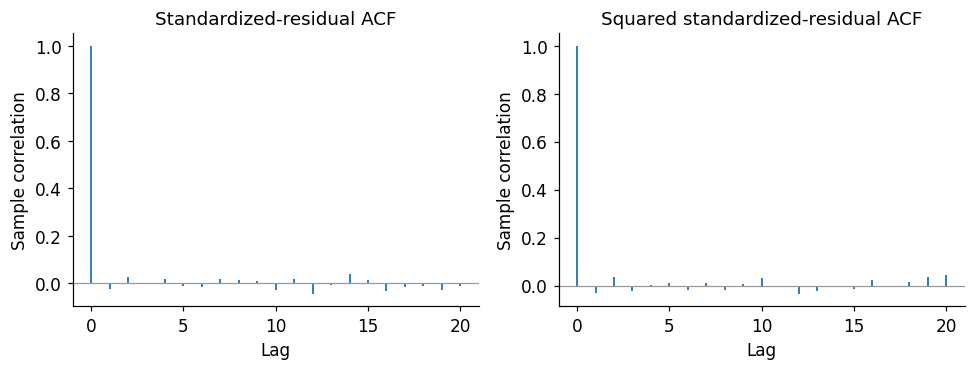

,Innovations,Series,statistic,p_value,df,lags,nobs
0,Gaussian,Standardized,14.760481,0.789945,20,20,1500
1,Gaussian,Squared standardized,16.003286,0.716420,20,20,1500
2,Student-t,Standardized,14.760757,0.789930,20,20,1500
3,Student-t,Squared standardized,16.040855,0.714086,20,20,1500


In [10]:
gaussian_standardized = standardized_residuals(np.asarray(gaussian_garch.resid), np.asarray(gaussian_garch.conditional_volatility))
student_standardized = standardized_residuals(np.asarray(student_garch.resid), np.asarray(student_garch.conditional_volatility))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
dependence_panel(axes[0], acf(gaussian_standardized, 20, adjusted=False), "Standardized-residual ACF")
dependence_panel(axes[1], acf(gaussian_standardized**2, 20, adjusted=False), "Squared standardized-residual ACF")
fig.tight_layout()
plt.show()
checks = []
for label, values, fit in (("Gaussian", gaussian_standardized, gaussian_garch), ("Student-t", student_standardized, student_garch)):
    squared_check = mcleod_li(values, 20)
    if fit.params.get("nu", np.inf) <= 4:
        squared_check["p_value"] = np.nan
    checks.extend([{"Innovations":label, "Series":"Standardized", **ljung_box(values, 20)}, {"Innovations":label, "Series":"Squared standardized", **squared_check}])
display(pd.DataFrame(checks))

### Volatility forecasting

For known parameters, the next variance is determined by observed information:
$$\hat\sigma_{t+1|t}^2=\hat\omega+\hat\alpha\hat a_t^2+\hat\beta\hat\sigma_t^2.$$
For $h\ge2$, conditional expectation replaces the future squared innovation by its variance:
$$\hat\sigma_{t+h|t}^2=\hat\omega+(\hat\alpha+\hat\beta)\hat\sigma_{t+h-1|t}^2.$$
When persistence is below one,
$$\hat\sigma_{t+h|t}^2=\hat\sigma_\infty^2+(\hat\alpha+\hat\beta)^{h-1}
(\hat\sigma_{t+1|t}^2-\hat\sigma_\infty^2).$$
This forecasts conditional variance, not a return. Square roots give conditional SD forecasts. Parameter uncertainty is not included in this plug-in recursion.



For illustration, I compare the Gaussian fit's explicit 20-step variance recursion with the package's residual-variance forecast. The distinction matters when a mean model propagates shocks: future return variance and future innovation variance need not coincide.

Max package / explicit variance forecast difference=1.11e-16
Max fitted / reconstructed variance difference=8.88e-16
One-step conditional variance=0.725357; persistence=0.962446


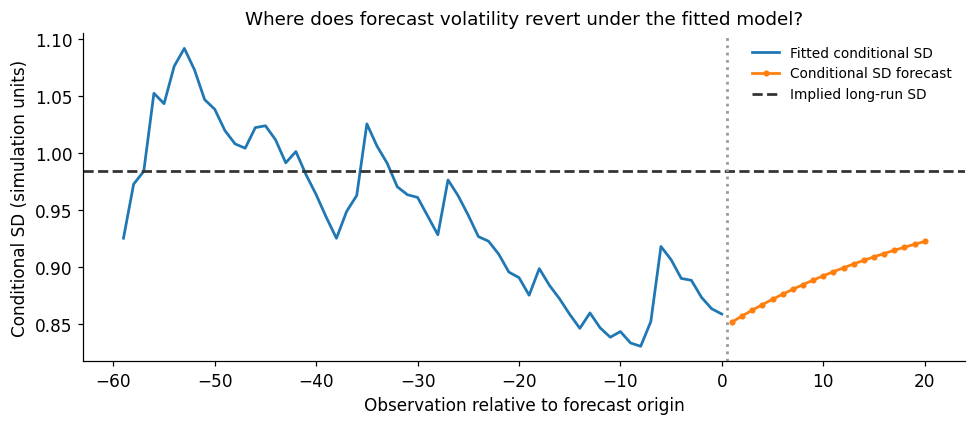

In [11]:
preferred_garch = gaussian_garch
params = preferred_garch.params
omega_hat, alpha_hat, beta_hat = params["omega"],params["alpha[1]"],params["beta[1]"]
valid = np.isfinite(preferred_garch.resid)&np.isfinite(preferred_garch.conditional_volatility)
fitted_residuals = np.asarray(preferred_garch.resid)[valid]
fitted_variances = np.asarray(preferred_garch.conditional_volatility)[valid]**2
variance_forecast = garch11_forecast(fitted_residuals[-1],fitted_variances[-1],omega_hat,alpha_hat,beta_hat,20)
package_variance_forecast = preferred_garch.forecast(horizon=20,reindex=False).residual_variance.iloc[-1].to_numpy()
np.testing.assert_allclose(variance_forecast,package_variance_forecast,rtol=1e-10,atol=1e-10)
reconstructed = garch11_variance_path(fitted_residuals,omega_hat,alpha_hat,beta_hat,initial_variance=fitted_variances[0])
np.testing.assert_allclose(reconstructed,fitted_variances,rtol=1e-8,atol=1e-8)
print(f"Max package / explicit variance forecast difference={np.max(abs(variance_forecast-package_variance_forecast)):.2e}")
print(f"Max fitted / reconstructed variance difference={np.max(abs(reconstructed-fitted_variances)):.2e}")
print(f"One-step conditional variance={variance_forecast[0]:.6f}; persistence={alpha_hat+beta_hat:.6f}")
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(np.arange(-59,1),np.sqrt(fitted_variances[-60:]),label="Fitted conditional SD")
ax.plot(np.arange(1,21),np.sqrt(variance_forecast),"o-",markersize=3,label="Conditional SD forecast")
if alpha_hat+beta_hat < 1-1e-6:
    long_run = garch11_unconditional_variance(omega_hat,alpha_hat,beta_hat)
    ax.axhline(np.sqrt(long_run),color="0.2",linestyle="--",label="Implied long-run SD")
ax.axvline(.5,color="0.6",linestyle=":")
ax.set(xlabel="Observation relative to forecast origin",ylabel="Conditional SD (simulation units)",title="Where does forecast volatility revert under the fitted model?")
ax.legend(fontsize=9);fig.tight_layout();plt.show()

The models describe conditional means and variances, while diagnostics assess remaining dependence and forecasts describe possible future observations. Notebook 09 combines these tools in one empirical financial workflow, with a fixed training/holdout split and explicit forecast evaluation.